# Suo

In [1]:
# working_directory = "/Users/kemalinecik/git_nosync/sctram"
working_directory = "/home/icb/kemal.inecik/work/codes/sctram"

In [2]:
import sys
sys.path.append(working_directory)

import logging
import gc
import os
import numpy as np
import pandas as pd
import networkx as nx
import scanpy as sc
import anndata as ad

sc.settings.verbose = 3

In [3]:
%matplotlib inline
%config InlineBackend.figure_format='retina'

import pickle

import matplotlib.pyplot as plt
import seaborn as sns

_rcparams_path = os.path.join(working_directory, "reproducibility/figure_rcparams/rcparams.pickle")
with open(_rcparams_path, "rb") as file:
    _rcparams = pickle.load(file)
plt.rcParams.update(_rcparams)

In [22]:
models = ["scvi", "scanvi", "X_pca", "harmony"]#, "invae", "tardis_1", "tardis_2"]

## UMAPs

In [23]:
dataset_dir = "/home/icb/kemal.inecik/lustre_workspace/temp_sctram_data"
adatas = {obsm_key: ad.read_h5ad(os.path.join(dataset_dir, f"suo_with_umap_{obsm_key}.h5ad")) for obsm_key in models}

AnnData object with n_obs × n_vars = 143750 × 24
    obs: 'sample_ID', 'organ', 'age', 'cell_type', 'sex', 'sex_inferred', 'concatenated_integration_covariates', 'integration_donor', 'integration_biological_unit', 'integration_sample_status', 'integration_library_platform_coarse', 'n_genes', '_scvi_batch', '_scvi_labels', 'LVL3', 'LVL2', 'LVL1', 'LVL0'
    uns: 'neighbors', 'umap'
    obsm: 'X_umap'
    obsp: 'connectivities', 'distances'


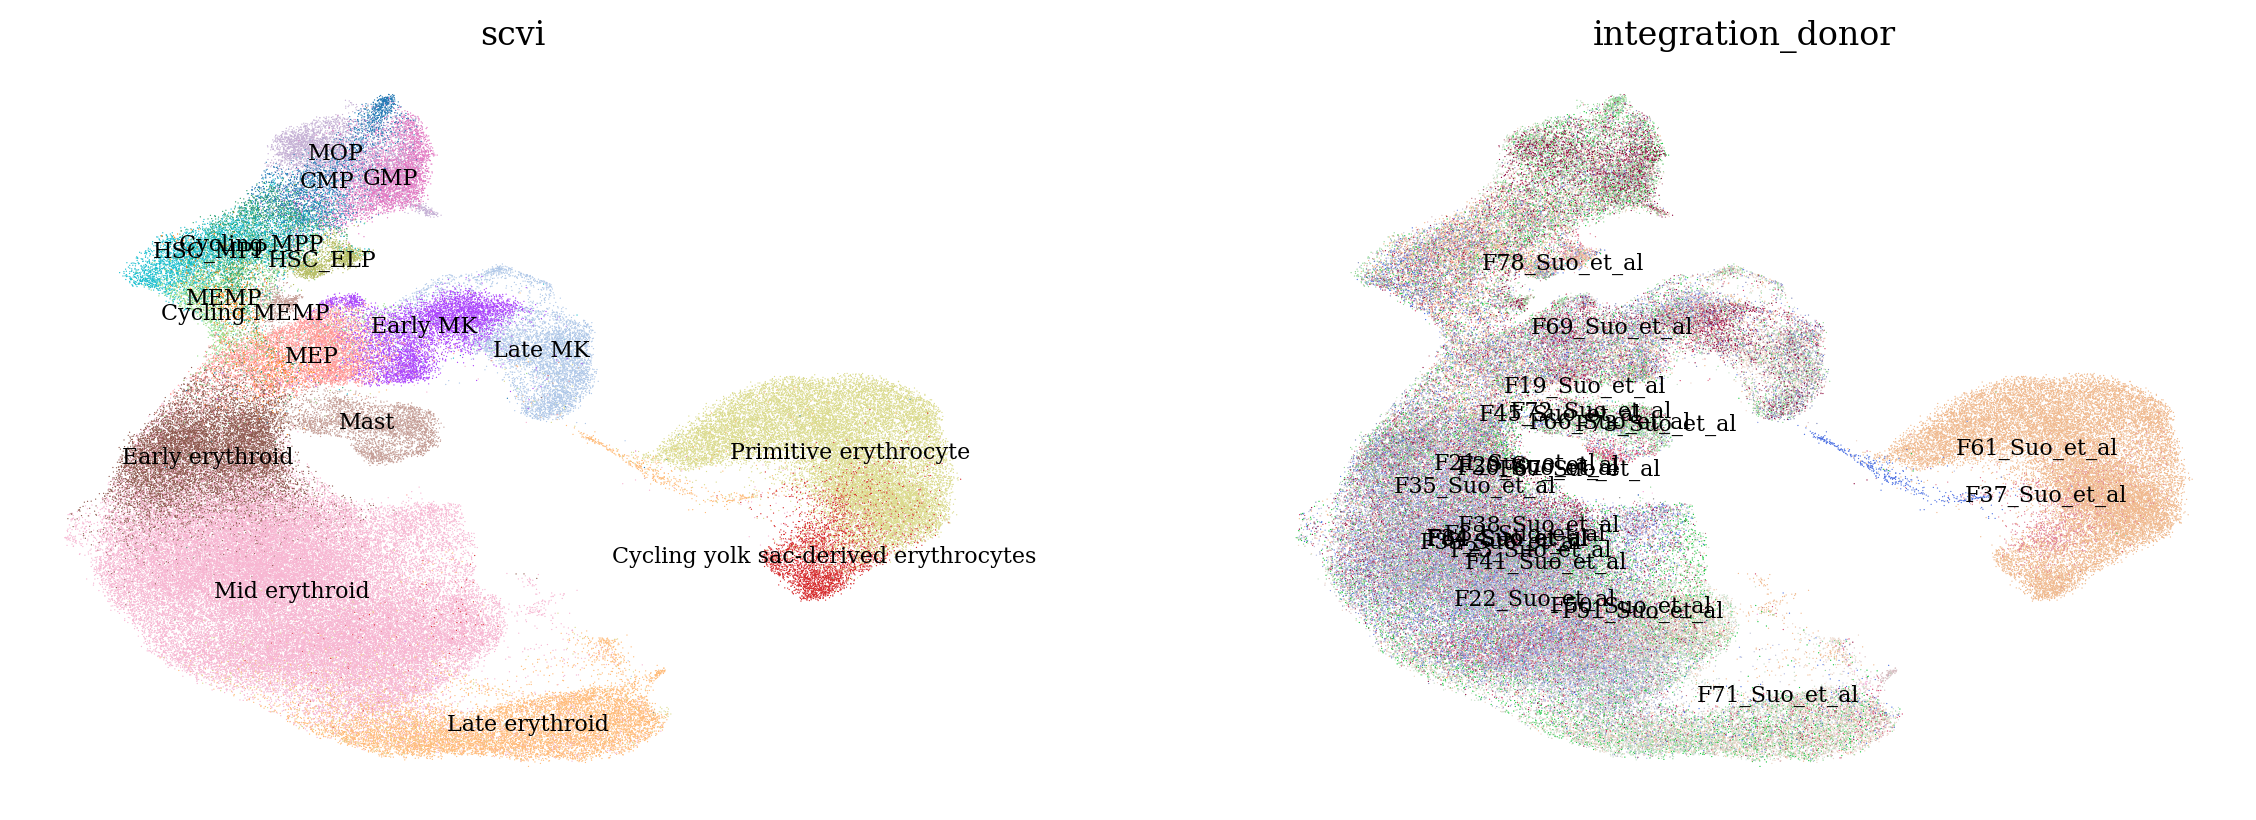

AnnData object with n_obs × n_vars = 143750 × 24
    obs: 'sample_ID', 'organ', 'age', 'cell_type', 'sex', 'sex_inferred', 'concatenated_integration_covariates', 'integration_donor', 'integration_biological_unit', 'integration_sample_status', 'integration_library_platform_coarse', 'n_genes', '_scvi_batch', '_scvi_labels', 'LVL3', 'LVL2', 'LVL1', 'LVL0'
    uns: 'neighbors', 'umap'
    obsm: 'X_umap'
    obsp: 'connectivities', 'distances'


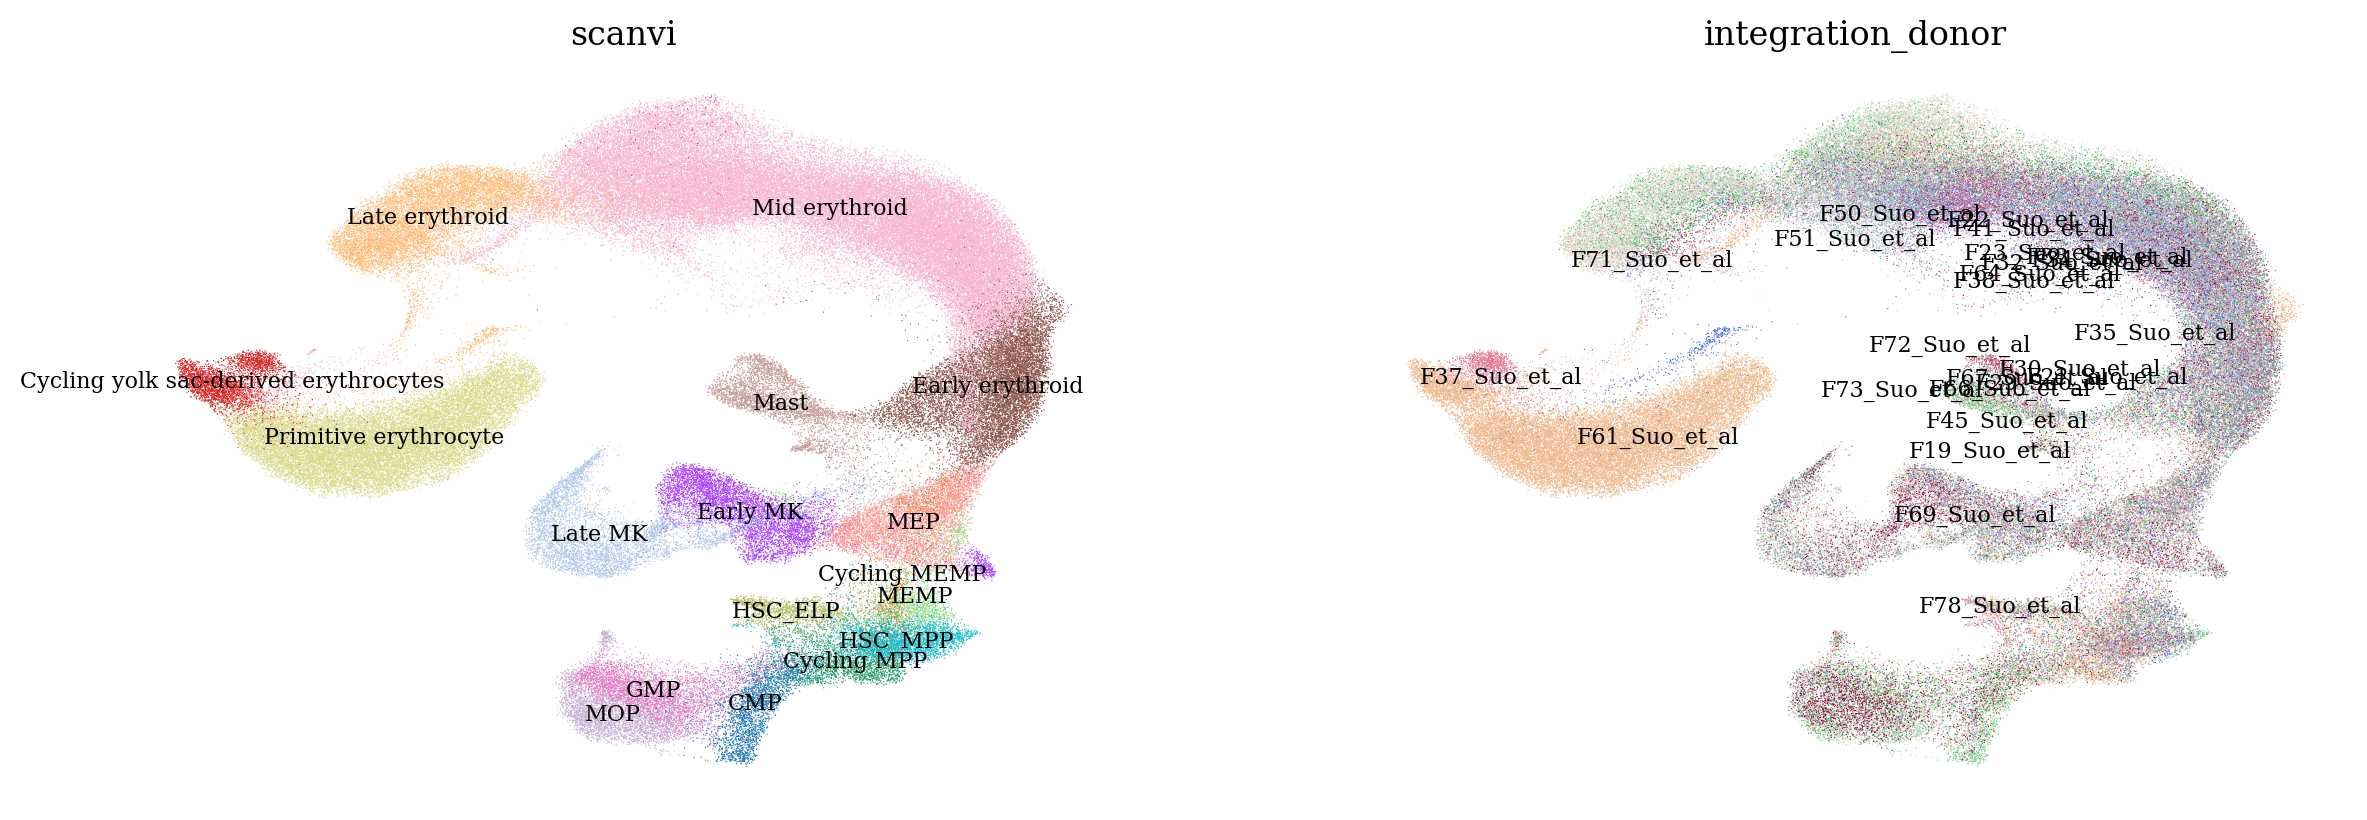

AnnData object with n_obs × n_vars = 143750 × 50
    obs: 'sample_ID', 'organ', 'age', 'cell_type', 'sex', 'sex_inferred', 'concatenated_integration_covariates', 'integration_donor', 'integration_biological_unit', 'integration_sample_status', 'integration_library_platform_coarse', 'n_genes', '_scvi_batch', '_scvi_labels', 'LVL3', 'LVL2', 'LVL1', 'LVL0'
    uns: 'neighbors', 'umap'
    obsm: 'X_umap'
    obsp: 'connectivities', 'distances'


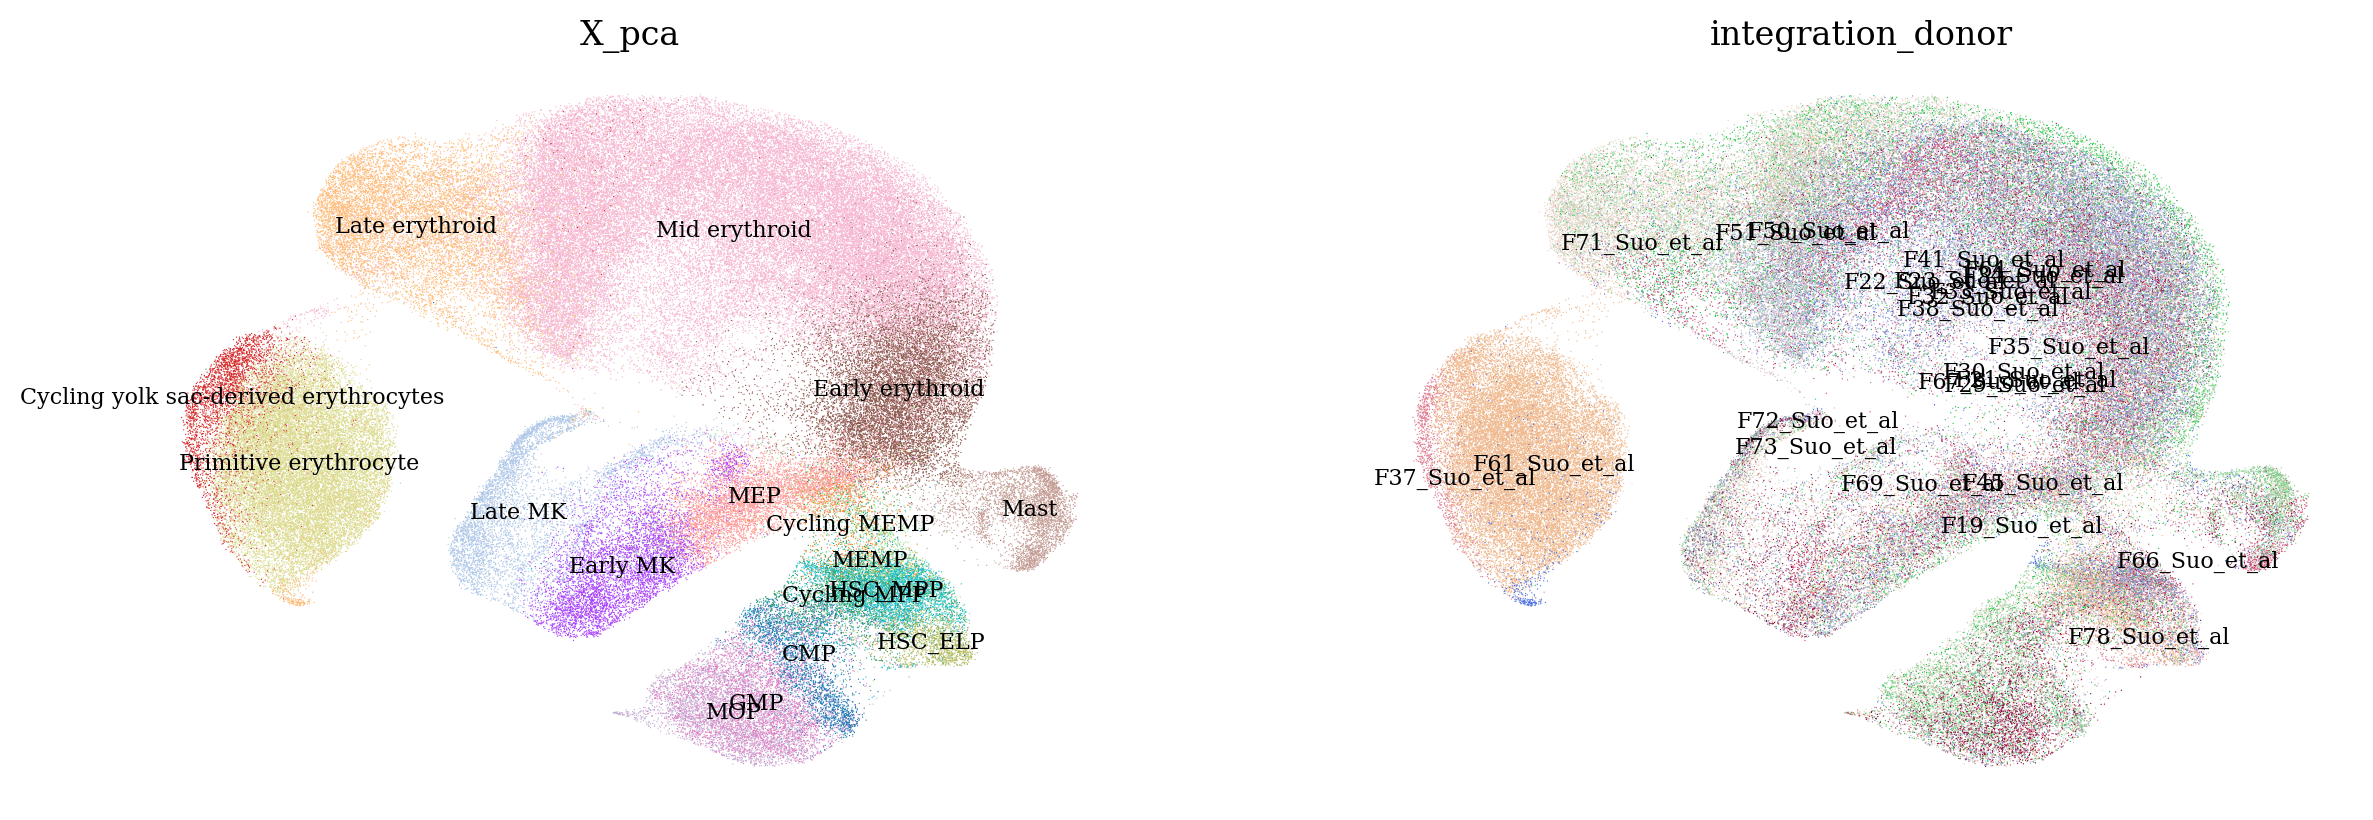

AnnData object with n_obs × n_vars = 143750 × 50
    obs: 'sample_ID', 'organ', 'age', 'cell_type', 'sex', 'sex_inferred', 'concatenated_integration_covariates', 'integration_donor', 'integration_biological_unit', 'integration_sample_status', 'integration_library_platform_coarse', 'n_genes', '_scvi_batch', '_scvi_labels', 'LVL3', 'LVL2', 'LVL1', 'LVL0'
    uns: 'neighbors', 'umap'
    obsm: 'X_umap'
    obsp: 'connectivities', 'distances'


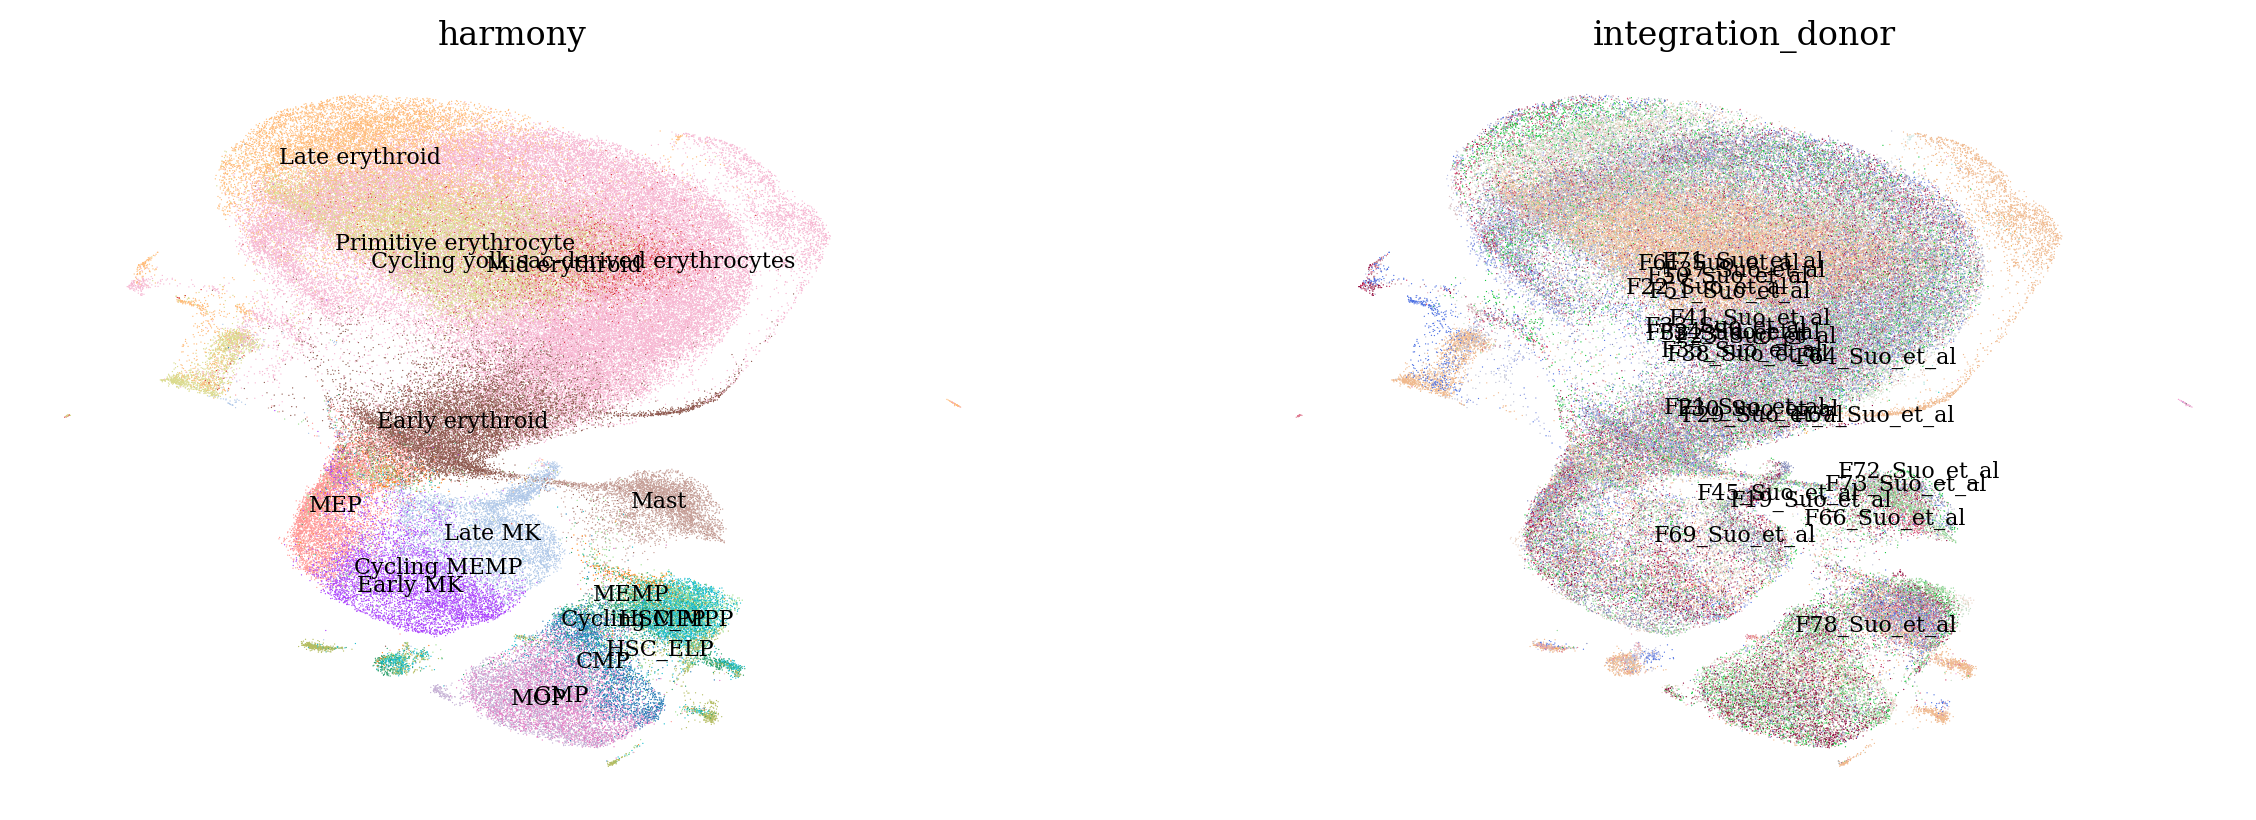

In [24]:
for obsm_key in models:
    print(adatas[obsm_key])
    sc.pl.embedding(
        adatas[obsm_key],
        basis='X_umap',
        color=["LVL3", "integration_donor"],
        frameon=False,
        legend_loc='on data',
        title=obsm_key,
        legend_fontsize=8,
        legend_fontweight=0
    )

## Calculations

In [25]:
!ls -lh /home/icb/kemal.inecik/lustre_workspace/temp_sctram_data/_metric_suo_*

-rw-r--r--. 1 kemal.inecik OG-ICB-User 2.2K Feb 16 12:42 /home/icb/kemal.inecik/lustre_workspace/temp_sctram_data/_metric_suo_harmony.pickle
-rw-r--r--. 1 kemal.inecik OG-ICB-User 2.2K Feb 16 16:04 /home/icb/kemal.inecik/lustre_workspace/temp_sctram_data/_metric_suo_invae.pickle
-rw-r--r--. 1 kemal.inecik OG-ICB-User 2.2K Feb 16 04:33 /home/icb/kemal.inecik/lustre_workspace/temp_sctram_data/_metric_suo_scanvi.pickle
-rw-r--r--. 1 kemal.inecik OG-ICB-User 2.2K Feb 16 01:04 /home/icb/kemal.inecik/lustre_workspace/temp_sctram_data/_metric_suo_scvi.pickle
-rw-r--r--. 1 kemal.inecik OG-ICB-User 2.2K Feb 16 20:04 /home/icb/kemal.inecik/lustre_workspace/temp_sctram_data/_metric_suo_tardis_1.pickle
-rw-r--r--. 1 kemal.inecik OG-ICB-User 2.2K Feb 17 00:06 /home/icb/kemal.inecik/lustre_workspace/temp_sctram_data/_metric_suo_tardis_2.pickle
-rw-r--r--. 1 kemal.inecik OG-ICB-User 2.2K Feb 16 08:37 /home/icb/kemal.inecik/lustre_workspace/temp_sctram_data/_metric_suo_X_pca.pickle


In [26]:
dataset_dir = "/home/icb/kemal.inecik/lustre_workspace/temp_sctram_data"
df = pd.DataFrame()
for obsm_key in models:
    _df = pd.read_pickle(os.path.join(dataset_dir, f"_metric_suo_{obsm_key}.pickle"))
    _df["model"] = obsm_key
    df = pd.concat([df, _df])
df.sort_values(by=["path", "metric"], inplace=True, ignore_index=True)
df.reset_index(drop=True, inplace=True)
df['score'] = pd.to_numeric(df['score'], errors='raise')

df_pivot = df.pivot(index=['path', 'metric'], columns='model', values='score')

In [27]:
def min_max_normalize(row):
    min_val = row.min()
    max_val = row.max()
    if max_val == min_val:
        return pd.Series(1, index=row.index) 
    else:
        return (row - min_val) / (max_val - min_val)
df_normalized = df_pivot.apply(min_max_normalize, axis=1)

In [28]:
def find_max_min_models(row):
    max_models = row[row == row.max()].index.tolist()
    min_models = row[row == row.min()].index.tolist()
    if sorted(min_models) == sorted(max_models):
        max_models, min_models= "", ""
    return pd.Series([max_models, min_models], index=['Max_Scoring_Models', 'Min_Scoring_Models'])
max_min_models = df_pivot.apply(find_max_min_models, axis=1)

with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.float_format', '{:.6f}'.format):
    assert np.all(max_min_models.index == df_normalized.index)
    display(pd.concat([max_min_models, df_pivot], axis=1))

Max_Scoring_Models  \
path       metric                                                     
adjacency  L1                                              [scanvi]   
           accuracy                          [X_pca, harmony, scvi]   
           avg_shortest_path_diff                                     
           clustering_coeff_diff                                      
           degree_emd                                      [scanvi]   
           f1_score                          [X_pca, harmony, scvi]   
           frobenius                                       [scanvi]   
           gnn_embedding_distance                                     
           graph_edit_distance                                        
           graphlet_degree_vector                                     
           hamming                                         [scanvi]   
           jaccard                                                    
           mantel_correlation                                [scvi]   
           maximum_common_subgraph_distance                           
           persistence_diagram_distance                               
           precision                                                  
           random_walk_kernel_distance                     [scanvi]   
           recall                            [X_pca, harmony, scvi]   
           spectral_distance                               [scanvi]   
           ssim                                           [harmony]   
           weisfeiler_lehman_distance                                 
embedding  branch_silhouette_score                         [scanvi]   
           distance_correlation                              [scvi]   
           gearys_c                                       [harmony]   
           getis_ord_gi_star                              [harmony]   
           leaf_node_separation                             [X_pca]   
           lisa                                            [scanvi]   
           morans_i                                        [scanvi]   
           neighborhood_preservation_score                  [X_pca]   
           normalized_mean_curvature                         [scvi]   
           stress                                         [harmony]   
           transition_smoothness                          [harmony]   
           trustworthiness                                            
pseudotime concordance_index                                [X_pca]   
           cramer_von_mises                                  [scvi]   
           cumulative_density_difference                  [harmony]   
           dynamic_time_warping                              [scvi]   
           gearys_c                                       [harmony]   
           getis_ord_gi_star                                [X_pca]   
           kendall                                          [X_pca]   
           lisa                                            [scanvi]   
           mae                                               [scvi]   
           morans_i                                        [scanvi]   
           mse                                               [scvi]   
           mutual_information_kde                           [X_pca]   
           normalized_mutual_information                   [scanvi]   
           pearson                                          [X_pca]   
           r2                                               [X_pca]   
           r2_with_spline                                   [X_pca]   
           spearman                                         [X_pca]   
           wasserstein_distance                              [scvi]   

                                                 Min_Scoring_Models  \
path       metric                                                     
adjacency  L1                                             [harmony]   
           accuracy                                        [scanvi]   
 

In [29]:
max_counts = {}
min_counts = {}

# Loop through the max_min_models DataFrame
for (path, metric), row in max_min_models.iterrows():
    if path not in max_counts:
        max_counts[path] = {}
        min_counts[path] = {}
    for model in df['model'].unique():
        if model not in max_counts[path]:
            max_counts[path][model] = 0
            min_counts[path][model] = 0
    for max_model in row['Max_Scoring_Models']:
        max_counts[path][max_model] += 1
    for min_model in row['Min_Scoring_Models']:
        min_counts[path][min_model] += 1

result_dfs = {}
for path in max_counts:
    result_dfs[path] = pd.DataFrame({
        'Max_Counts': pd.Series(max_counts[path]),
        'Min_Counts': pd.Series(min_counts[path])
    })

for p in result_dfs.keys():
    print(p)
    display(result_dfs[p])

adjacency


,Max_Counts,Min_Counts
scvi,4,4
scanvi,6,5
X_pca,3,1
harmony,4,3


embedding


,Max_Counts,Min_Counts
scvi,2,5
scanvi,3,1
X_pca,2,3
harmony,4,2


pseudotime


,Max_Counts,Min_Counts
scvi,5,7
scanvi,3,2
X_pca,8,4
harmony,2,5


In [30]:
max_counts = {}
min_counts = {}
models = df['model'].unique()

# Initialize counters for each model
for model in models:
    max_counts[model] = 0
    min_counts[model] = 0

# Count occurrences of each model being named as max and min
for index, row in max_min_models.iterrows():
    for max_model in row['Max_Scoring_Models']:
        max_counts[max_model] += 1
    for min_model in row['Min_Scoring_Models']:
        min_counts[min_model] += 1

# Convert to DataFrame for nice display
result_df = pd.DataFrame({
    'Max_Counts': pd.Series(max_counts),
    'Min_Counts': pd.Series(min_counts)
})
result_df

,Max_Counts,Min_Counts
scvi,11,16
scanvi,12,8
X_pca,13,8
harmony,10,10
